Testes com FER 2013 obtido pelo Kaggle

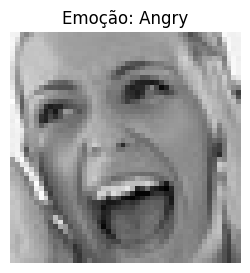

Imagem aleatória lida com sucesso!


In [105]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 1. Defina o caminho para a pasta onde você extraiu o dataset.
# Geralmente o Kaggle descompacta criando pastas 'train' e 'test'.
# Ajuste o caminho abaixo se a sua pasta estiver em outro lugar.
caminho_base = './fer2013/train'

# 2. Escolhendo uma pasta de emoção aleatória dentro do caminho_base
pastas_emocoes = [
    nome for nome in os.listdir(caminho_base)
    if os.path.isdir(os.path.join(caminho_base, nome))
]

if pastas_emocoes:
    emocao_teste = random.choice(pastas_emocoes)
    caminho_pasta_emocao = os.path.join(caminho_base, emocao_teste)

    # 3. Selecionando uma imagem aleatória dentro da pasta escolhida
    imagens = [
        nome for nome in os.listdir(caminho_pasta_emocao)
        if os.path.isfile(os.path.join(caminho_pasta_emocao, nome))
    ]
    if imagens:
        imagem_nome = random.choice(imagens)
        caminho_imagem_completo = os.path.join(caminho_pasta_emocao, imagem_nome)
    else:
        print(f"Nenhuma imagem encontrada na pasta {caminho_pasta_emocao}.")
        caminho_imagem_completo = None
else:
    print(f"Nenhuma pasta de emoção encontrada em {caminho_base}.")
    caminho_imagem_completo = None

# 4. Carregando a imagem local, se existir
if caminho_imagem_completo:
    imagem = mpimg.imread(caminho_imagem_completo)

    # 5. Exibindo a imagem na tela
    plt.figure(figsize=(3, 3))
    plt.imshow(imagem, cmap='gray') # O dataset é em tons de cinza [cite: 230]
    plt.title(f"Emoção: {emocao_teste.capitalize()}")
    plt.axis('off') # Escondendo os eixos visuais
    plt.show()

    print("Imagem aleatória lida com sucesso!")
else:
    print("Não foi possível carregar uma imagem.")

Distribuição das classes e balanceamento

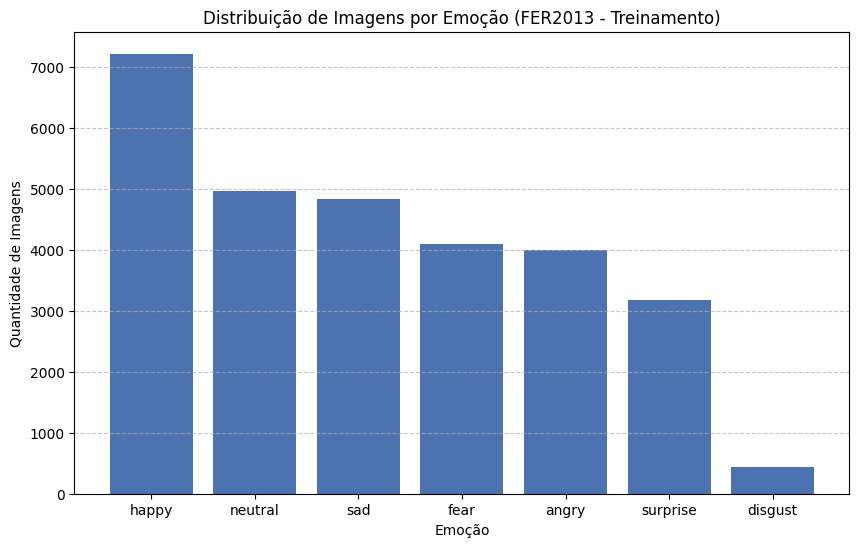

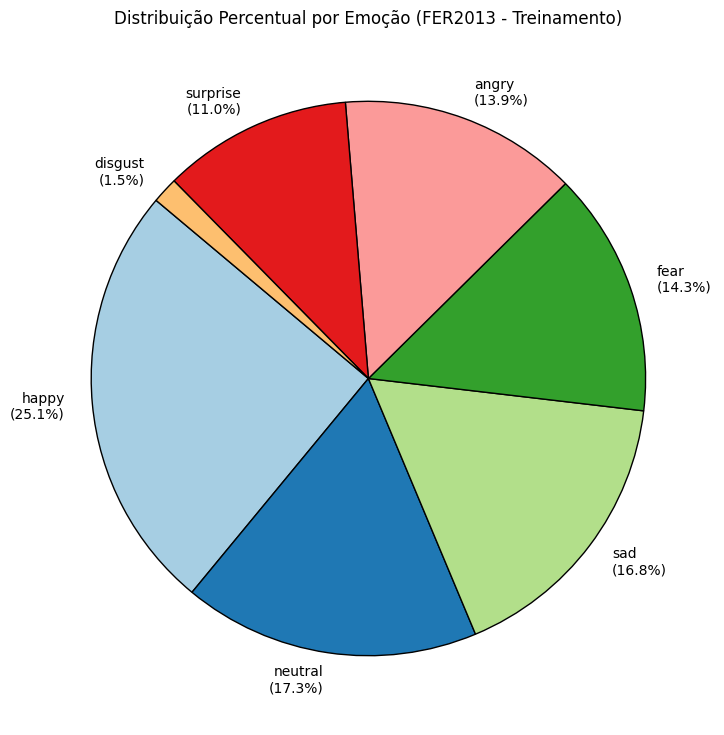

Análise preliminar do balanceamento concluída!


In [4]:
import os
import matplotlib.pyplot as plt

# 1. Definindo o caminho da pasta de treino
caminho_treino = './fer2013/train'

# 2. Dicionário para guardar a contagem
contagem_emocoes = {}

# 3. Varrendo as pastas e contando os arquivos
for emocao in os.listdir(caminho_treino):
    caminho_emocao = os.path.join(caminho_treino, emocao)

    # Verifica se é realmente uma pasta (ignora arquivos soltos)
    if os.path.isdir(caminho_emocao):
        quantidade_imagens = len(os.listdir(caminho_emocao))
        contagem_emocoes[emocao] = quantidade_imagens

# 4. Ordenando os dados do maior para o menor para o gráfico ficar elegante
contagem_ordenada = dict(sorted(contagem_emocoes.items(), key=lambda item: item[1], reverse=True))

# 5. Gerando o gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(contagem_ordenada.keys(), contagem_ordenada.values(), color='#4C72B0')
plt.title('Distribuição de Imagens por Emoção (FER2013 - Treinamento)')
plt.xlabel('Emoção')
plt.ylabel('Quantidade de Imagens')
plt.grid(axis='y', linestyle='--', alpha=0.7)


# plt.savefig('distribuicao_classes_fer2013.png', dpi=300, bbox_inches='tight')

plt.show()

# 6. Gráfico de setores (Pizza) com rótulos externos

# Calculando o total para descobrir as porcentagens manualmente
total_imagens = sum(contagem_ordenada.values())

# Criando novas labels que já incluem a quebra de linha (\n) e a porcentagem
novas_labels = [f"{emocao}\n({(qtd / total_imagens) * 100:.1f}%)" for emocao, qtd in contagem_ordenada.items()]

plt.figure(figsize=(9, 9)) # Aumentei levemente para dar espaço aos novos rótulos
plt.pie(
    contagem_ordenada.values(),
    labels=novas_labels,       # Usando as labels personalizadas
    startangle=140,
    colors=plt.cm.Paired.colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
plt.title('Distribuição Percentual por Emoção (FER2013 - Treinamento)')

# plt.savefig('distribuicao_percentual_fer2013.png', dpi=300, bbox_inches='tight')

plt.show()
print("Análise preliminar do balanceamento concluída!")